In [1]:
import importlib
import quantum_function
importlib.reload(quantum_function)

from quantum_function import *
from IPython.display import display, Markdown

In [2]:
# --- SAFETY SWITCH: esce subito se non abiliti esplicitamente ---
RUN_THIS_CELL = True   # metti True solo quando vuoi davvero eseguire

if not RUN_THIS_CELL:
    display(Markdown("Cell locked. Set `RUN_THIS_CELL = True` to run"))
    raise SystemExit

plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",      # font simile a LaTeX
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False
})

<font size="6">***Homodyne detection - 2 qubits, single dephasing***

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

In [3]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    "store_final_state" : True,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}


ntraj = 10

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = False,
        
        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   1.90s. Est. time left: 00:00:00:07
30.0%. Run time:   3.65s. Est. time left: 00:00:00:08
40.0%. Run time:   5.32s. Est. time left: 00:00:00:07
50.0%. Run time:   6.96s. Est. time left: 00:00:00:06
60.0%. Run time:   8.76s. Est. time left: 00:00:00:05
70.0%. Run time:  10.55s. Est. time left: 00:00:00:04
80.0%. Run time:  12.32s. Est. time left: 00:00:00:03
90.0%. Run time:  14.04s. Est. time left: 00:00:00:01
100.0%. Run time:  15.77s. Est. time left: 00:00:00:00
Total run time:  17.53s
10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   1.75s. Est. time left: 00:00:00:07
30.0%. Run time:   3.41s. Est. time left: 00:00:00:07
40.0%. Run time:   5.41s. Est. time left: 00:00:00:08
50.0%. Run time:   7.01s. Est. time left: 00:00:00:07
60.0%. Run time:   8.59s. Est. time left: 00:00:00:05
70.0%. Run time:  10.31s. Est. time left: 00:00:00:04
80.0%. Run time:  12.71s. Est. time left: 00:00:00:03
90.

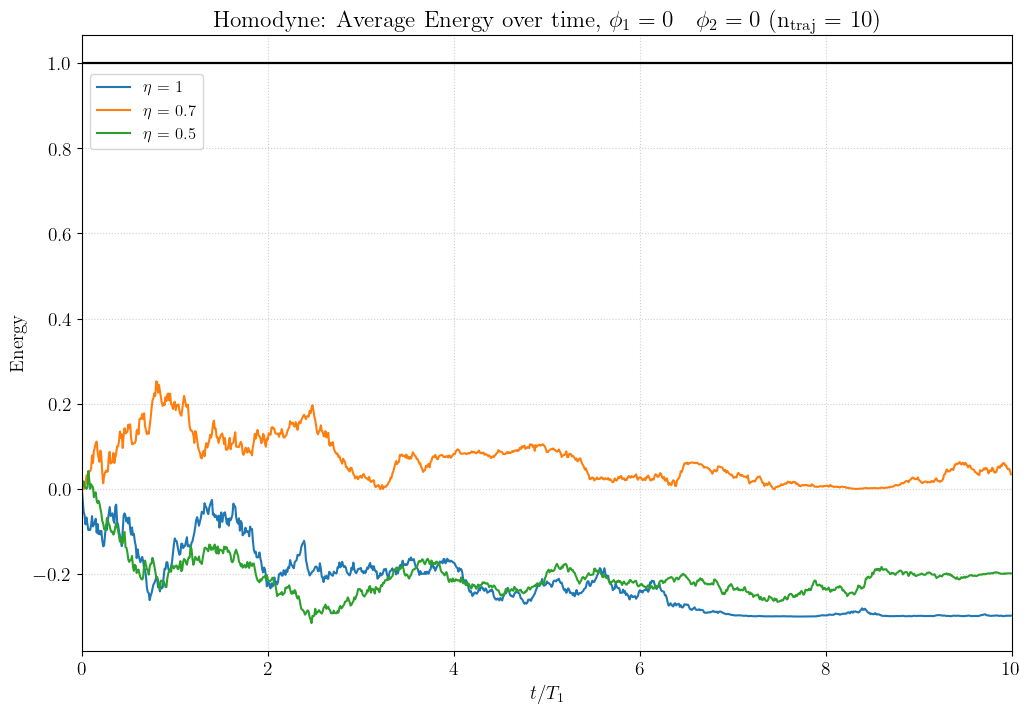

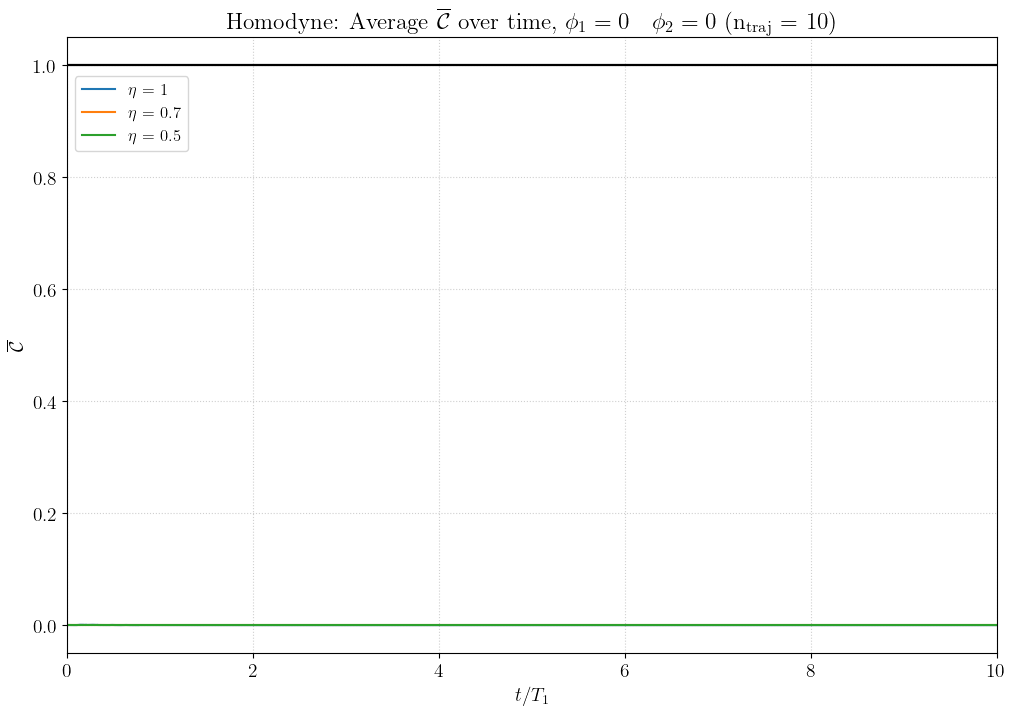

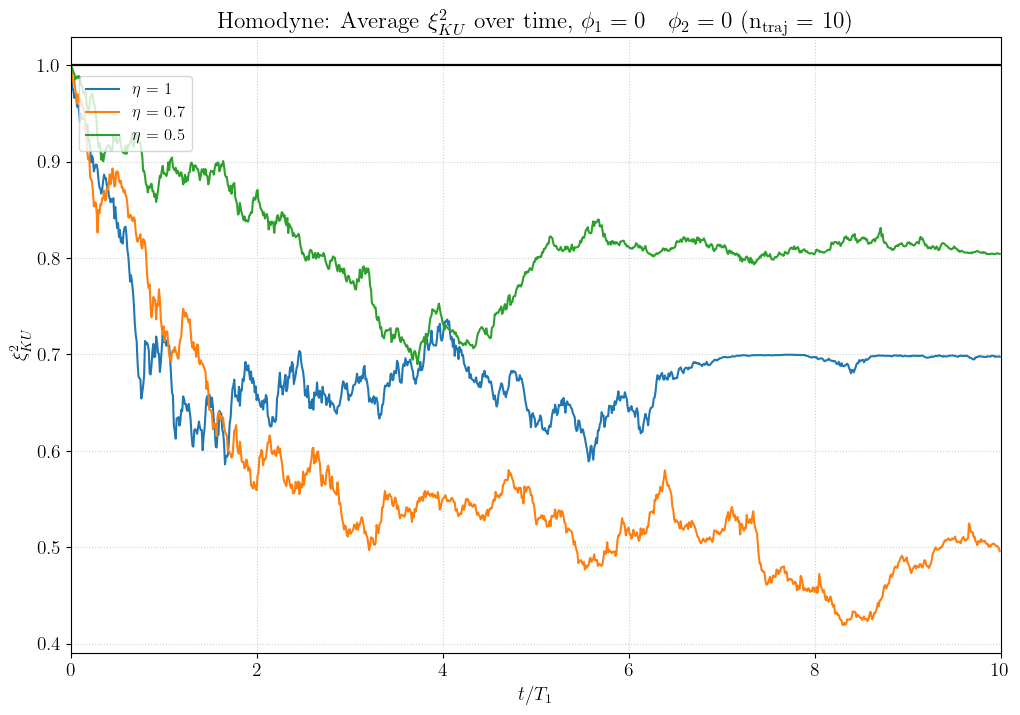

In [4]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Hom_PlusPlus\\phi_1=0_phi_2=0"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Hom_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Homodyne: Average " + label_graph_column[e_op]+ r" over time, "+ rf"$\phi_1 = 0 \quad \phi_2 = 0$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = \pi/2$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = i\,\hat{C}_-
\end{aligned}
\right.
$$

In [5]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = False,
        
        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  24.54s. Est. time left: 00:00:03:40
20.0%. Run time:  51.87s. Est. time left: 00:00:03:27
30.0%. Run time:  83.04s. Est. time left: 00:00:03:13
40.0%. Run time: 110.62s. Est. time left: 00:00:02:45
50.0%. Run time: 139.38s. Est. time left: 00:00:02:19
60.0%. Run time: 159.82s. Est. time left: 00:00:01:46
70.0%. Run time: 176.00s. Est. time left: 00:00:01:15
80.0%. Run time: 193.20s. Est. time left: 00:00:00:48
90.0%. Run time: 208.66s. Est. time left: 00:00:00:23
100.0%. Run time: 223.41s. Est. time left: 00:00:00:00
Total run time: 225.20s
10.0%. Run time:  14.70s. Est. time left: 00:00:02:12
20.0%. Run time:  34.49s. Est. time left: 00:00:02:17
30.0%. Run time:  58.32s. Est. time left: 00:00:02:16
40.0%. Run time:  77.35s. Est. time left: 00:00:01:56
50.0%. Run time:  93.34s. Est. time left: 00:00:01:33
60.0%. Run time: 112.00s. Est. time left: 00:00:01:14
70.0%. Run time: 130.98s. Est. time left: 00:00:00:56
80.0%. Run time: 154.48s. Est. time left: 00:00:00:38
90.

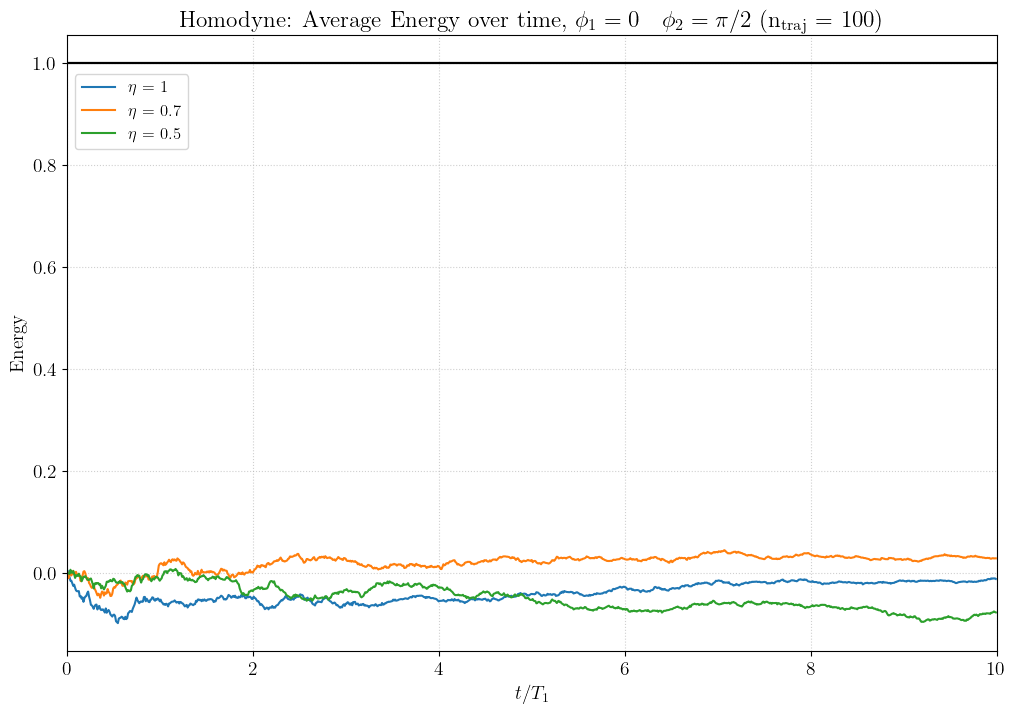

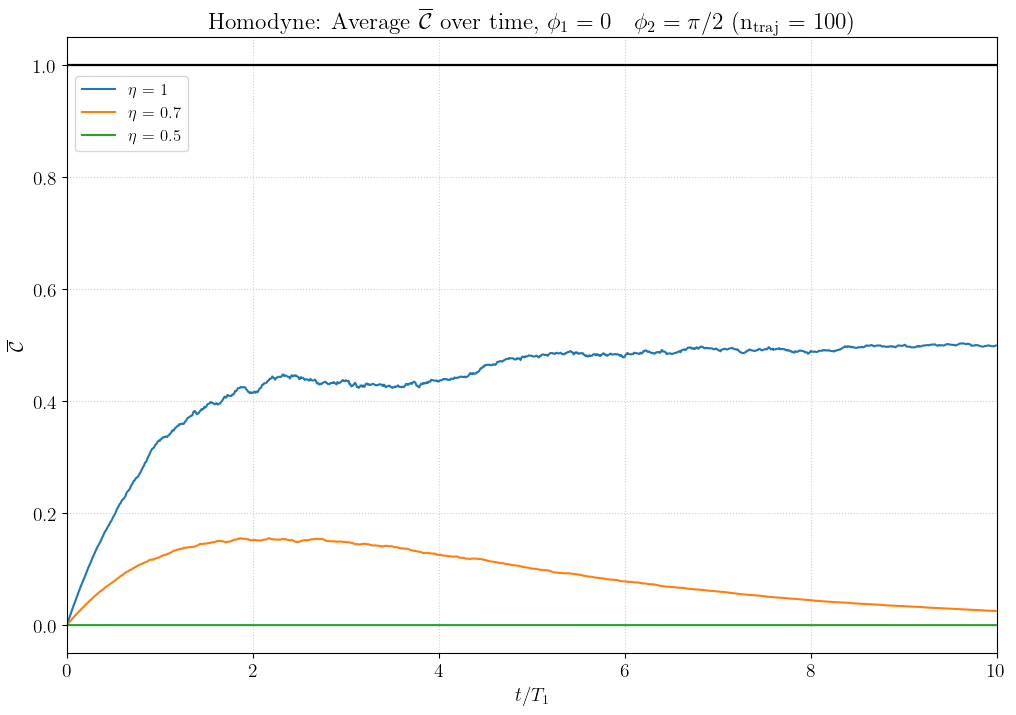

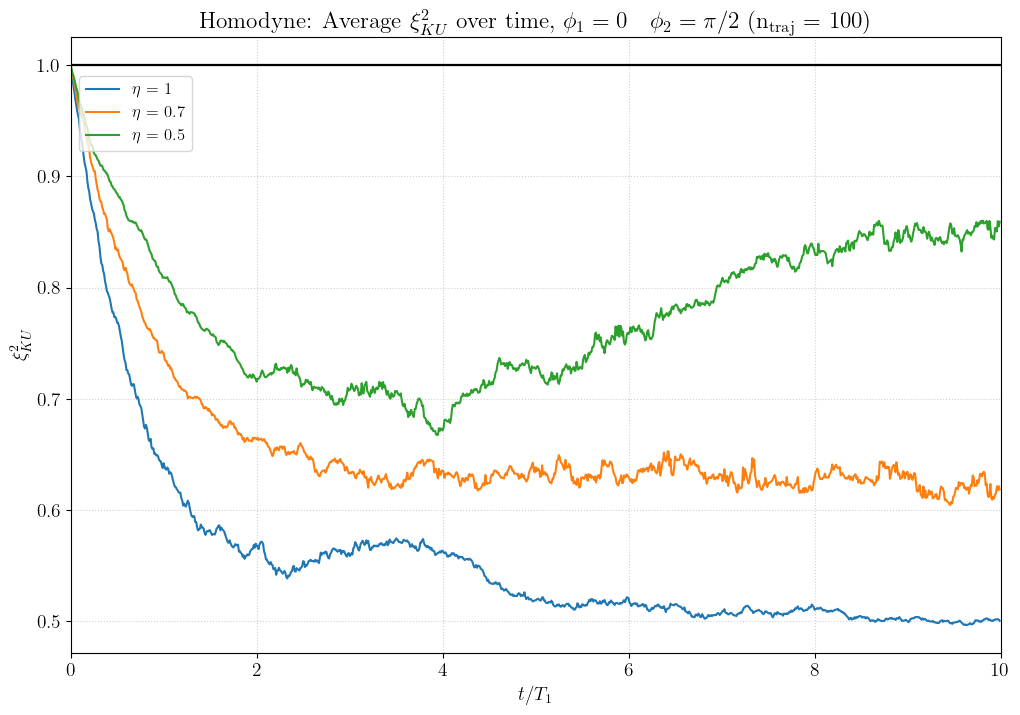

In [6]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Hom_PlusPlus\\phi_1=0_phi_2=pi2"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Hom_{e_op}_phi_1=0_phi_2=pi2"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Homodyne: Average " + label_graph_column[e_op]+ r" over time, "+ rf"$\phi_1 = 0 \quad \phi_2 = \pi / 2$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = \pi/2 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = i\hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

In [ ]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    "store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = False,

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  21.27s. Est. time left: 00:00:03:11
20.0%. Run time:  45.48s. Est. time left: 00:00:03:01
30.0%. Run time:  69.69s. Est. time left: 00:00:02:42
40.0%. Run time:  96.66s. Est. time left: 00:00:02:24
50.0%. Run time: 121.17s. Est. time left: 00:00:02:01
60.0%. Run time: 144.05s. Est. time left: 00:00:01:36
70.0%. Run time: 167.80s. Est. time left: 00:00:01:11
80.0%. Run time: 186.60s. Est. time left: 00:00:00:46
90.0%. Run time: 204.71s. Est. time left: 00:00:00:22
100.0%. Run time: 225.38s. Est. time left: 00:00:00:00
Total run time: 227.91s
10.0%. Run time:  20.00s. Est. time left: 00:00:03:00
20.0%. Run time:  45.08s. Est. time left: 00:00:03:00
30.0%. Run time:  69.80s. Est. time left: 00:00:02:42
40.0%. Run time:  91.84s. Est. time left: 00:00:02:17
50.0%. Run time: 116.01s. Est. time left: 00:00:01:56
60.0%. Run time: 138.92s. Est. time left: 00:00:01:32
70.0%. Run time: 161.02s. Est. time left: 00:00:01:09
80.0%. Run time: 185.94s. Est. time left: 00:00:00:46
90.

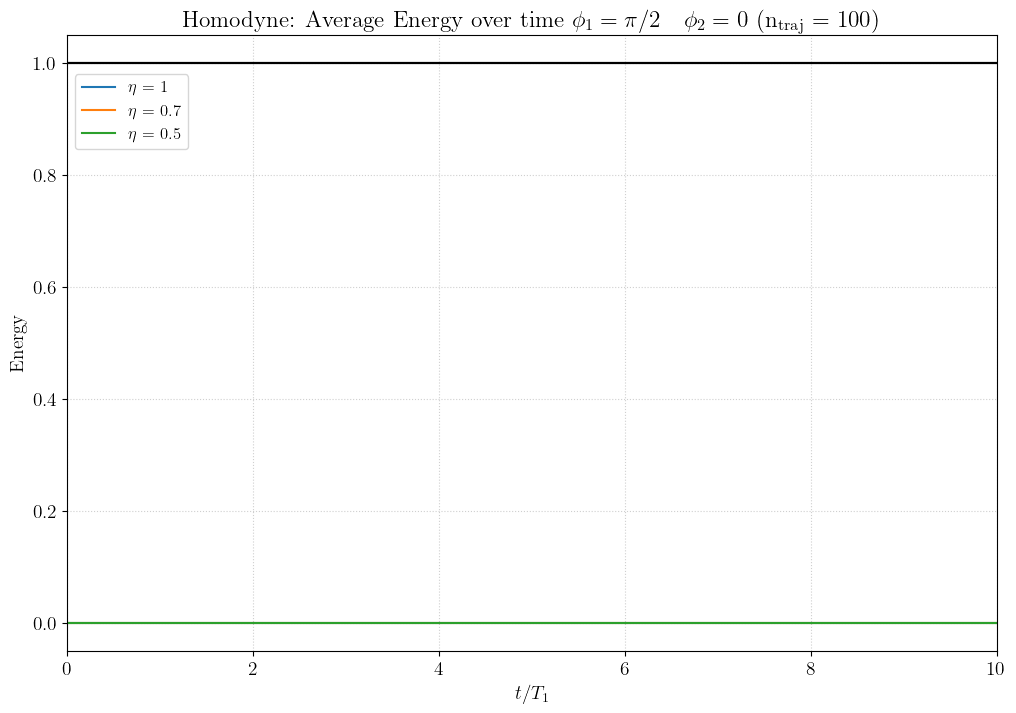

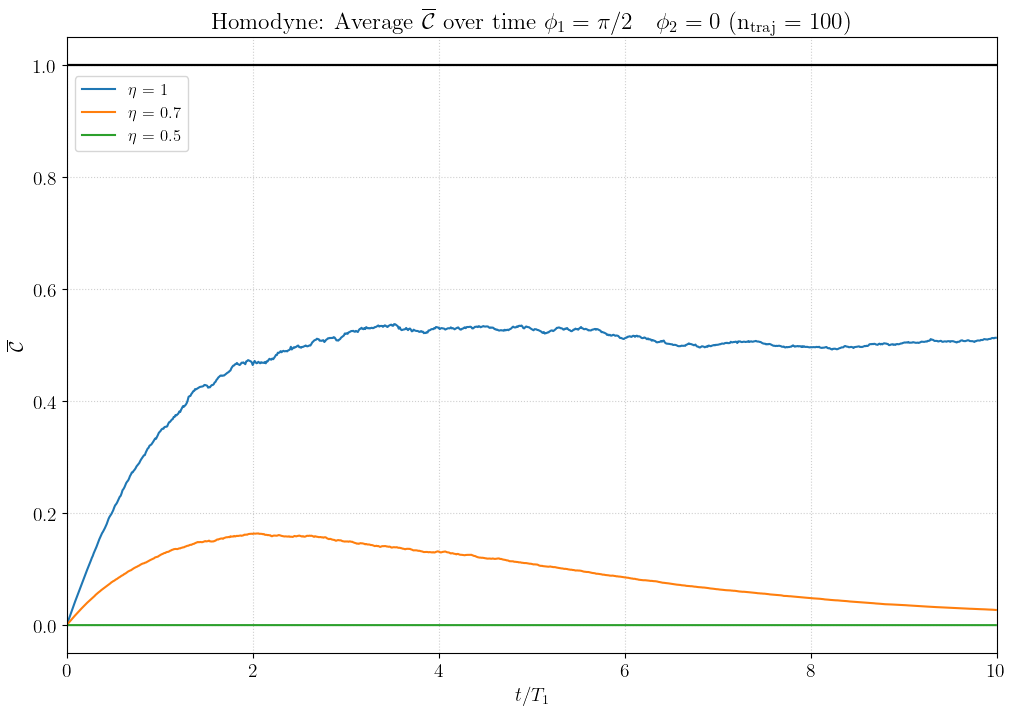

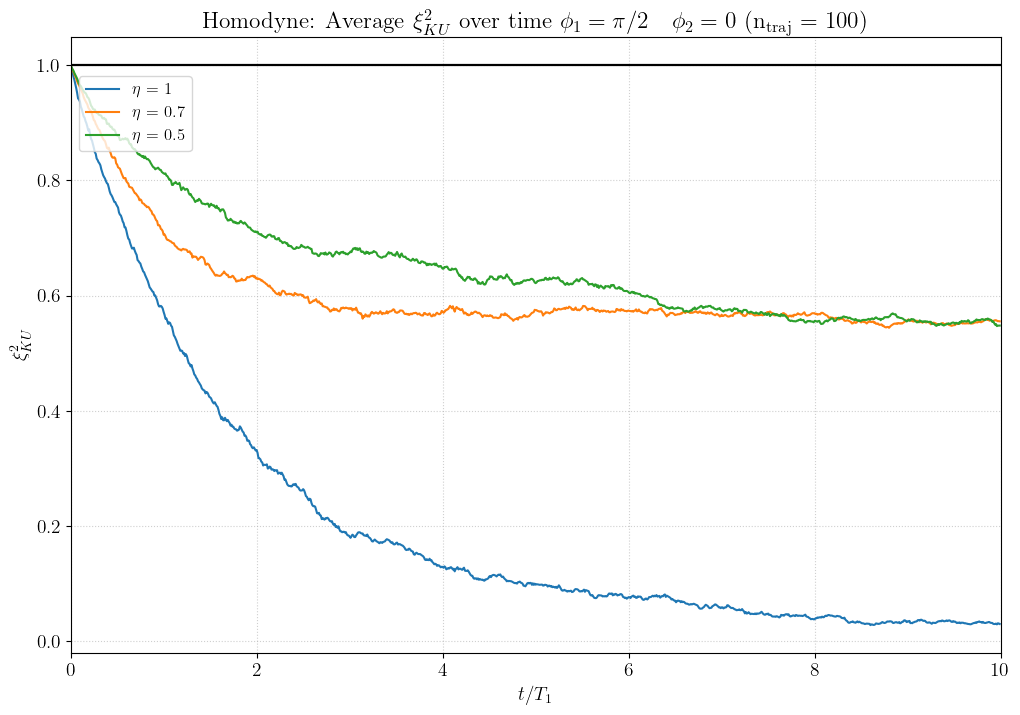

In [8]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Hom_PlusPlus\\phi_1=pi_2_phi_2=0"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Homodyne: Average " + label_graph_column[e_op]+ r" over time"+ rf" $\phi_1 = \pi / 2 \quad \phi_2 = 0$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = \pi/2 \quad \phi_2 = \pi/2$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = i\hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = i\hat{C}_-
\end{aligned}
\right.
$$

In [9]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = False,

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  23.10s. Est. time left: 00:00:03:27
20.0%. Run time:  47.35s. Est. time left: 00:00:03:09
30.0%. Run time:  71.30s. Est. time left: 00:00:02:46
40.0%. Run time:  95.46s. Est. time left: 00:00:02:23
50.0%. Run time: 119.67s. Est. time left: 00:00:01:59
60.0%. Run time: 139.73s. Est. time left: 00:00:01:33
70.0%. Run time: 161.19s. Est. time left: 00:00:01:09
80.0%. Run time: 181.43s. Est. time left: 00:00:00:45
90.0%. Run time: 202.53s. Est. time left: 00:00:00:22
100.0%. Run time: 224.20s. Est. time left: 00:00:00:00
Total run time: 226.63s
10.0%. Run time:  19.20s. Est. time left: 00:00:02:52
20.0%. Run time:  40.57s. Est. time left: 00:00:02:42
30.0%. Run time:  64.76s. Est. time left: 00:00:02:31
40.0%. Run time:  85.80s. Est. time left: 00:00:02:08
50.0%. Run time: 108.64s. Est. time left: 00:00:01:48
60.0%. Run time: 131.46s. Est. time left: 00:00:01:27
70.0%. Run time: 151.97s. Est. time left: 00:00:01:05
80.0%. Run time: 173.69s. Est. time left: 00:00:00:43
90.

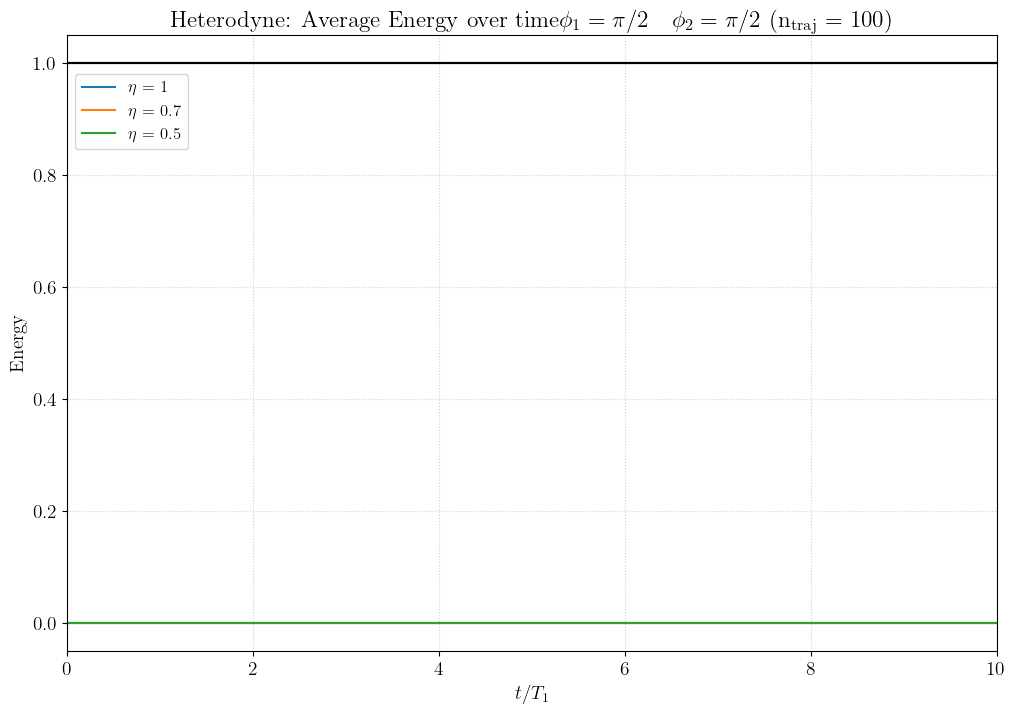

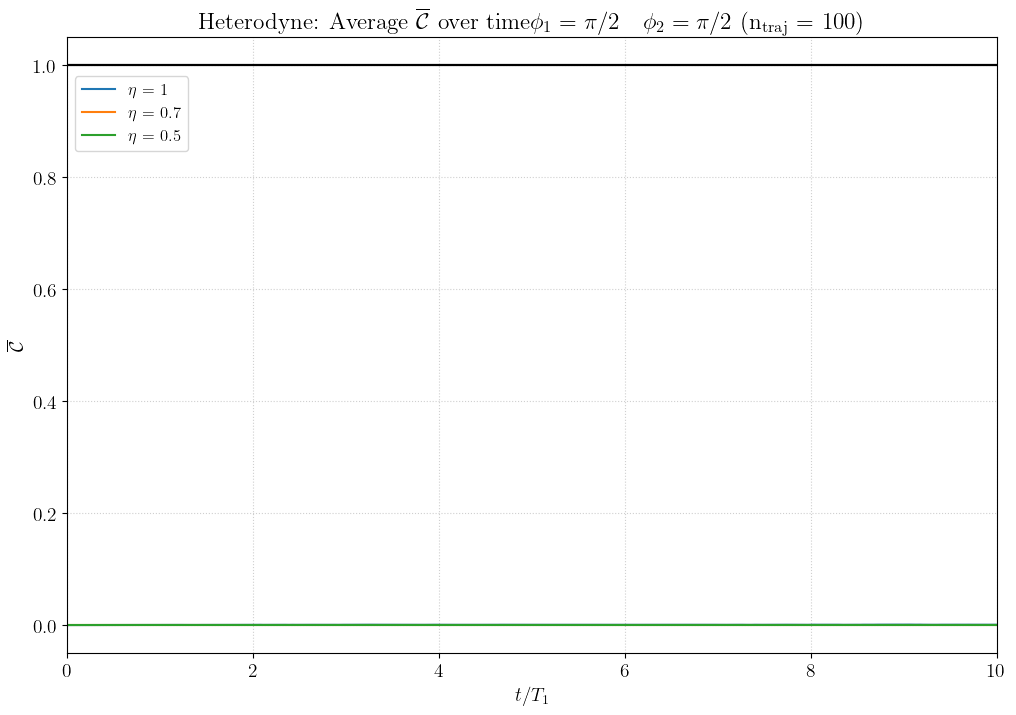

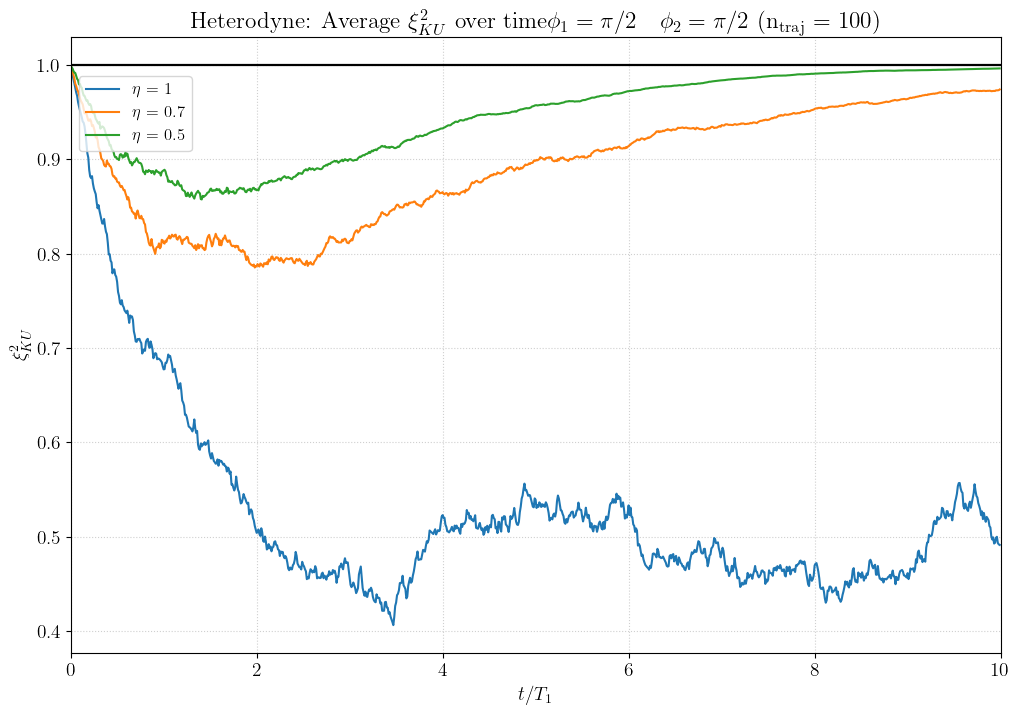

In [10]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Hom_PlusPlus\\phi_1=pi_2_phi_2=pi_2"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Heterodyne: Average " + label_graph_column[e_op]+ r" over time"+ rf"$ \phi_1 = \pi / 2 \quad \phi_2 = \pi / 2$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

<font size="6">***Heterodyne detection - 2 qubits, single dephasing***

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

In [11]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = True,
        
        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  35.38s. Est. time left: 00:00:05:18
20.0%. Run time:  71.52s. Est. time left: 00:00:04:46
30.0%. Run time: 109.71s. Est. time left: 00:00:04:15
40.0%. Run time: 150.67s. Est. time left: 00:00:03:46
50.0%. Run time: 192.68s. Est. time left: 00:00:03:12
60.0%. Run time: 233.64s. Est. time left: 00:00:02:35
70.0%. Run time: 276.24s. Est. time left: 00:00:01:58
80.0%. Run time: 312.86s. Est. time left: 00:00:01:18
90.0%. Run time: 349.03s. Est. time left: 00:00:00:38
100.0%. Run time: 385.47s. Est. time left: 00:00:00:00
Total run time: 389.54s
10.0%. Run time:  32.04s. Est. time left: 00:00:04:48
20.0%. Run time:  71.17s. Est. time left: 00:00:04:44
30.0%. Run time: 108.06s. Est. time left: 00:00:04:12
40.0%. Run time: 143.51s. Est. time left: 00:00:03:35
50.0%. Run time: 181.74s. Est. time left: 00:00:03:01
60.0%. Run time: 219.12s. Est. time left: 00:00:02:26
70.0%. Run time: 256.29s. Est. time left: 00:00:01:49
80.0%. Run time: 294.84s. Est. time left: 00:00:01:13
90.

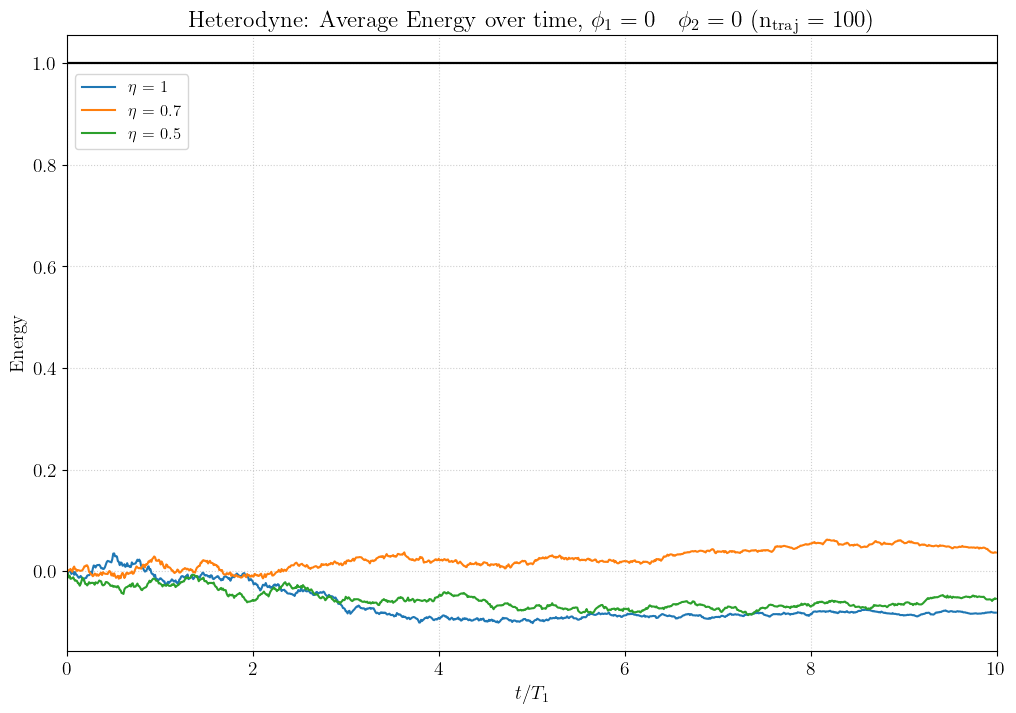

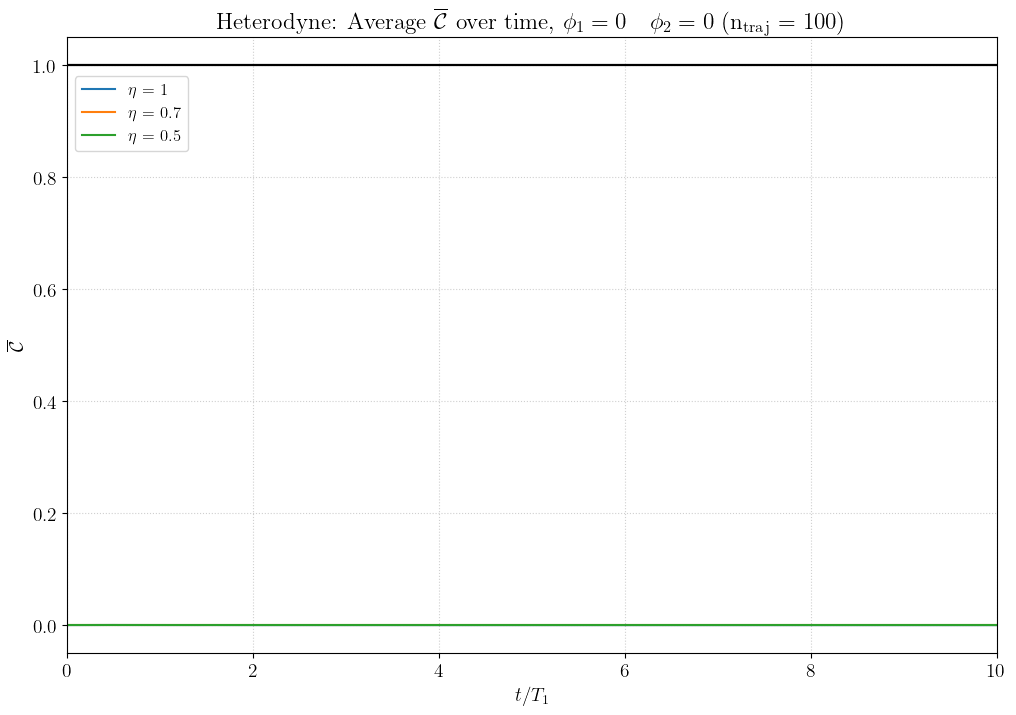

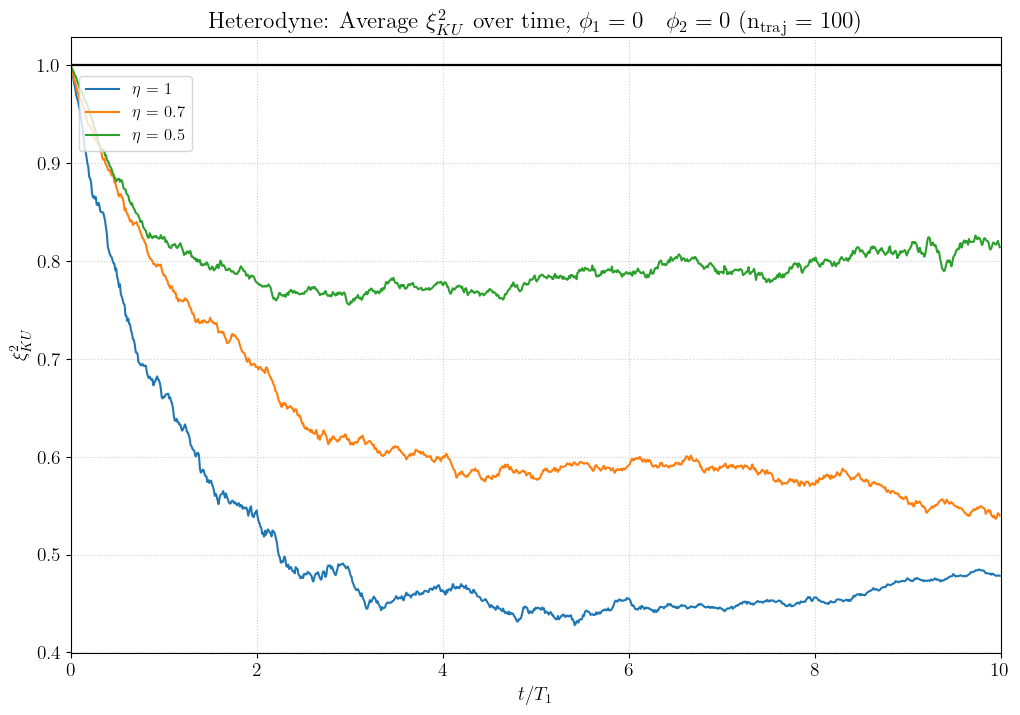

In [12]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Het_PlusPlus\\phi_1=0_phi_2=0"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Hom_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Heterodyne: Average " + label_graph_column[e_op]+ r" over time, "+ rf"$\phi_1 = 0 \quad \phi_2 = 0$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = \pi/2$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = i\,\hat{C}_-
\end{aligned}
\right.
$$

In [13]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = True,
        
        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  35.33s. Est. time left: 00:00:05:17
20.0%. Run time:  74.32s. Est. time left: 00:00:04:57
30.0%. Run time: 112.10s. Est. time left: 00:00:04:21
40.0%. Run time: 150.54s. Est. time left: 00:00:03:45
50.0%. Run time: 186.65s. Est. time left: 00:00:03:06
60.0%. Run time: 223.05s. Est. time left: 00:00:02:28
70.0%. Run time: 261.89s. Est. time left: 00:00:01:52
80.0%. Run time: 300.44s. Est. time left: 00:00:01:15
90.0%. Run time: 336.58s. Est. time left: 00:00:00:37
100.0%. Run time: 372.61s. Est. time left: 00:00:00:00
Total run time: 376.69s
10.0%. Run time:  34.57s. Est. time left: 00:00:05:11
20.0%. Run time:  71.86s. Est. time left: 00:00:04:47
30.0%. Run time: 108.77s. Est. time left: 00:00:04:13
40.0%. Run time: 152.09s. Est. time left: 00:00:03:48
50.0%. Run time: 193.28s. Est. time left: 00:00:03:13
60.0%. Run time: 234.91s. Est. time left: 00:00:02:36
70.0%. Run time: 276.16s. Est. time left: 00:00:01:58
80.0%. Run time: 316.37s. Est. time left: 00:00:01:19
90.

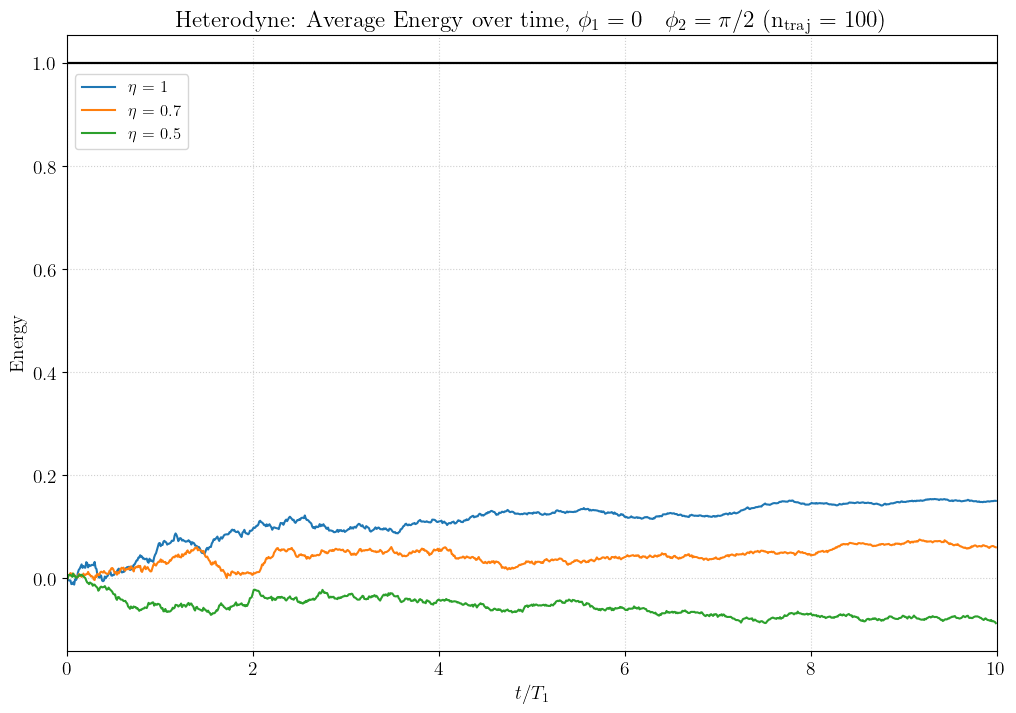

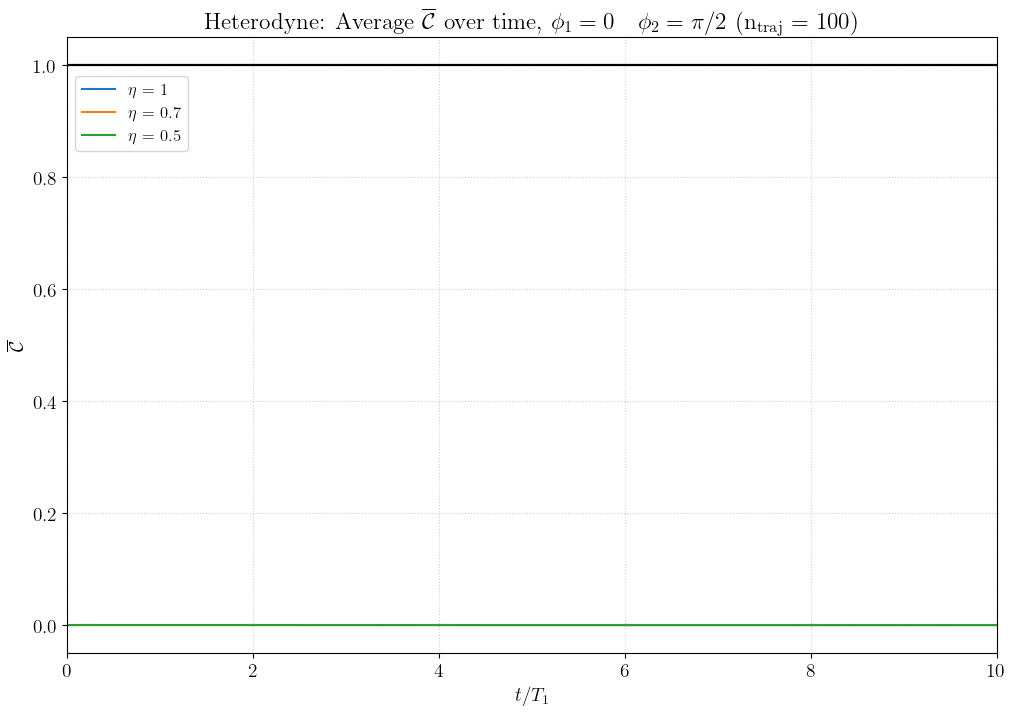

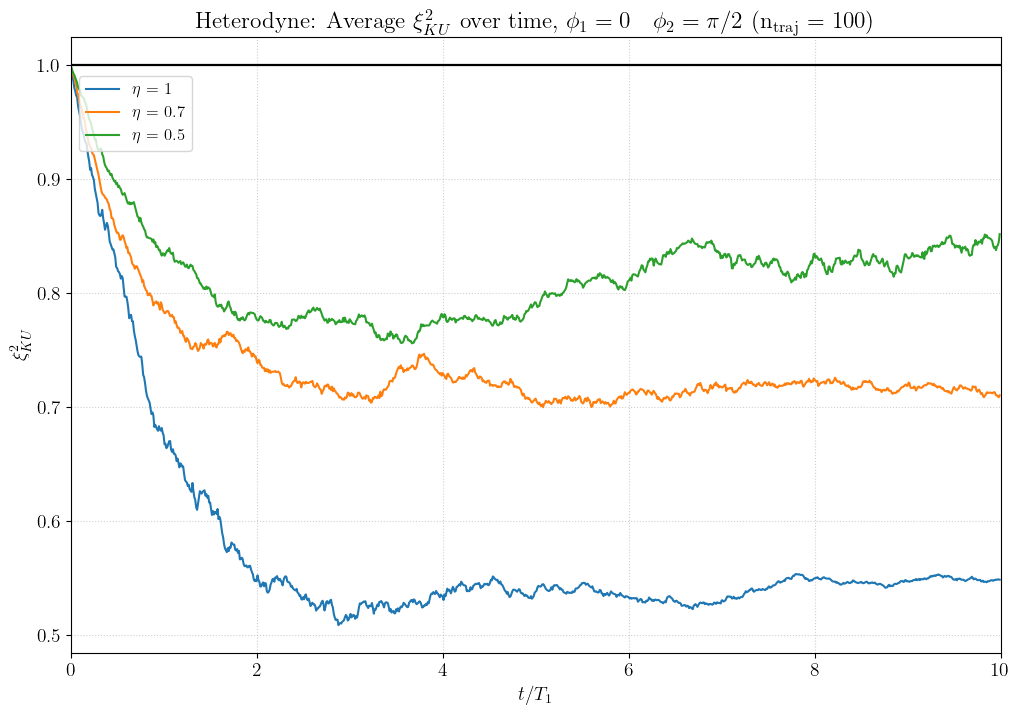

In [14]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Het_PlusPlus\\phi_1=0_phi_2=pi2"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Hom_{e_op}_phi_1=0_phi_2=pi2"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Heterodyne: Average " + label_graph_column[e_op]+ r" over time, "+ rf"$\phi_1 = 0 \quad \phi_2 = \pi / 2$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = \pi/2 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = i\hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

In [15]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = True,

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  37.01s. Est. time left: 00:00:05:33
20.0%. Run time:  75.51s. Est. time left: 00:00:05:02
30.0%. Run time: 112.36s. Est. time left: 00:00:04:22
40.0%. Run time: 149.63s. Est. time left: 00:00:03:44
50.0%. Run time: 183.61s. Est. time left: 00:00:03:03
60.0%. Run time: 215.14s. Est. time left: 00:00:02:23
70.0%. Run time: 249.80s. Est. time left: 00:00:01:47
80.0%. Run time: 283.51s. Est. time left: 00:00:01:10
90.0%. Run time: 320.57s. Est. time left: 00:00:00:35
100.0%. Run time: 353.57s. Est. time left: 00:00:00:00
Total run time: 357.28s
10.0%. Run time:  28.67s. Est. time left: 00:00:04:18
20.0%. Run time:  61.71s. Est. time left: 00:00:04:06
30.0%. Run time:  95.42s. Est. time left: 00:00:03:42
40.0%. Run time: 127.91s. Est. time left: 00:00:03:11
50.0%. Run time: 160.64s. Est. time left: 00:00:02:40
60.0%. Run time: 193.13s. Est. time left: 00:00:02:08
70.0%. Run time: 227.18s. Est. time left: 00:00:01:37
80.0%. Run time: 258.39s. Est. time left: 00:00:01:04
90.

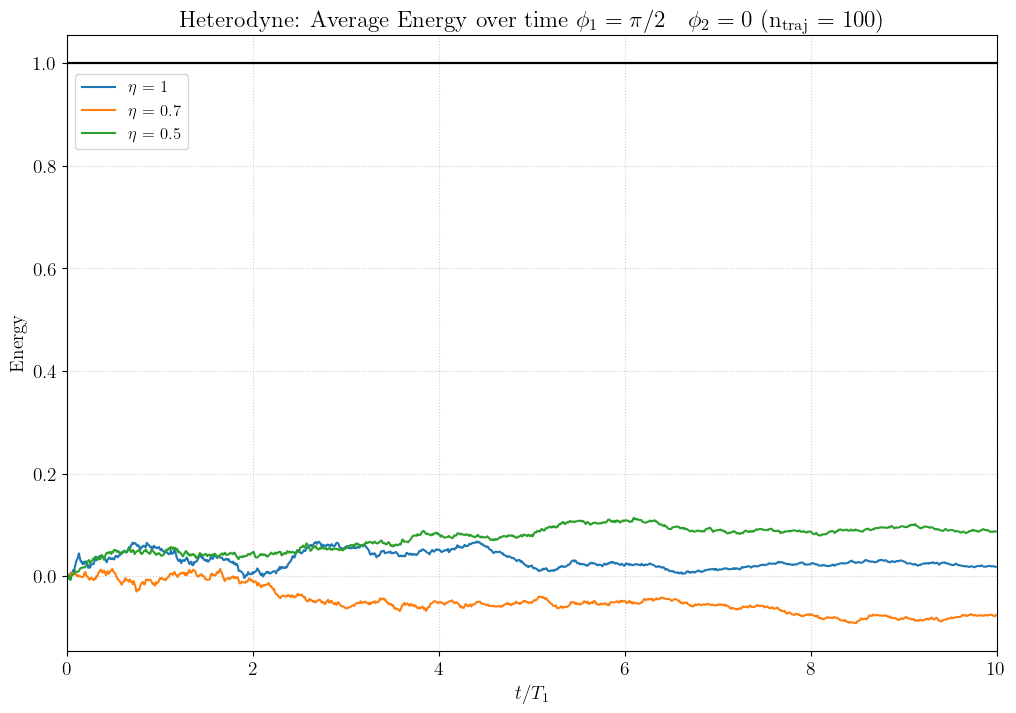

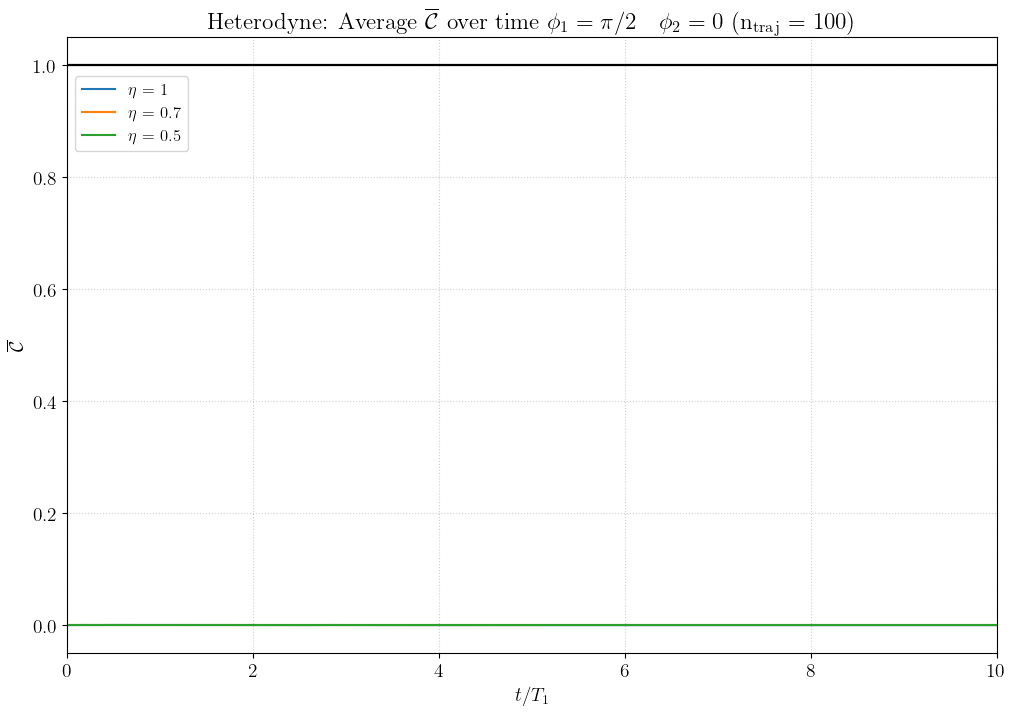

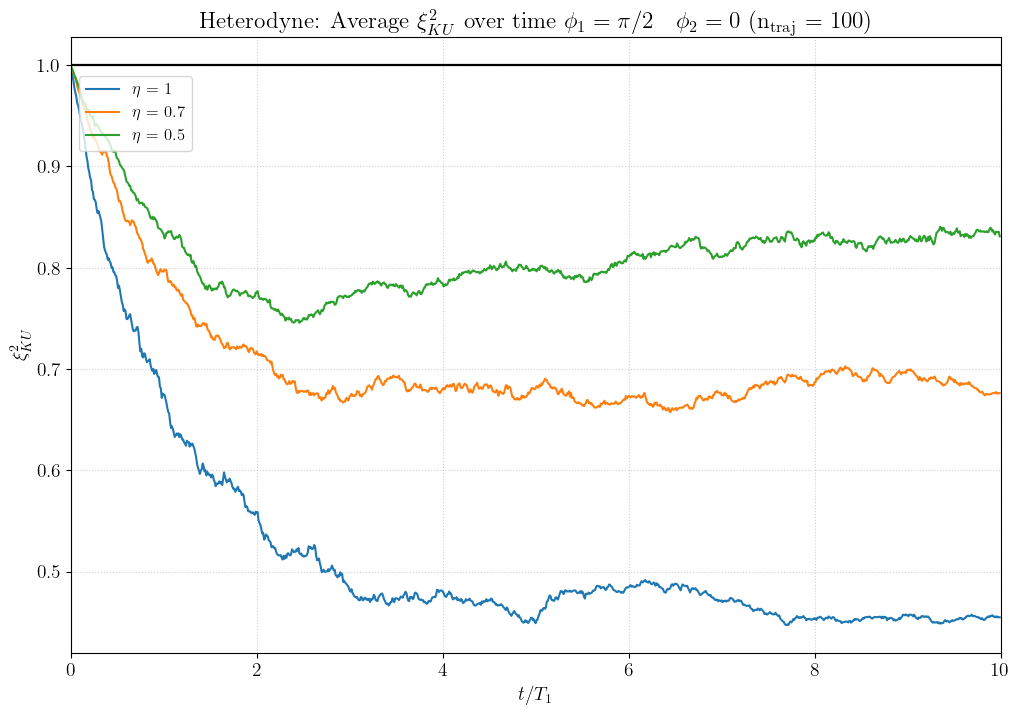

In [16]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Het_PlusPlus\\phi_1=pi_2_phi_2=0"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Heterodyne: Average " + label_graph_column[e_op]+ r" over time"+ rf" $\phi_1 = \pi / 2 \quad \phi_2 = 0$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = \pi/2 \quad \phi_2 = \pi/2$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = i\hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = i\hat{C}_-
\end{aligned}
\right.
$$

In [17]:
#1000 in 2 min

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) 

my_label_eta = ["1", "0.7", "0.5"] 

my_eta = [1, 0.7, 0.5] #etas for the homodyne detection

state = PlusPlus

ineff_df = {}

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = ["Energy",
                 "Conc",
                 "Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus"
            ]

label_graph_column = {
    "Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$"
}

my_e_ops = [energy_solver, concurrence_for_solver_general, xi_KU_solver]


ntraj = 100

for eta,label in zip(my_eta, my_label_eta):
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*(1-eta) / 2) * (Sz_1-Sz_2)
        ],

        sc_ops = [
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta / 2) * (Sz_1+Sz_2),
        np.exp(1j * np.pi/2)*np.sqrt(gamma*eta/ 2) * (Sz_1-Sz_2)
        ],

        heterodyne = True,

        e_ops=my_e_ops,
        ntraj=ntraj,
        options=my_opts_dict
    )

    ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

10.0%. Run time:  32.58s. Est. time left: 00:00:04:53
20.0%. Run time:  65.20s. Est. time left: 00:00:04:20
30.0%. Run time:  98.15s. Est. time left: 00:00:03:49
40.0%. Run time: 131.40s. Est. time left: 00:00:03:17
50.0%. Run time: 165.01s. Est. time left: 00:00:02:45
60.0%. Run time: 198.54s. Est. time left: 00:00:02:12
70.0%. Run time: 234.19s. Est. time left: 00:00:01:40
80.0%. Run time: 267.40s. Est. time left: 00:00:01:06
90.0%. Run time: 301.72s. Est. time left: 00:00:00:33
100.0%. Run time: 333.02s. Est. time left: 00:00:00:00
Total run time: 336.12s
10.0%. Run time:  28.30s. Est. time left: 00:00:04:14
20.0%. Run time:  62.60s. Est. time left: 00:00:04:10
30.0%. Run time:  99.52s. Est. time left: 00:00:03:52
40.0%. Run time: 133.36s. Est. time left: 00:00:03:20
50.0%. Run time: 167.89s. Est. time left: 00:00:02:47
60.0%. Run time: 201.81s. Est. time left: 00:00:02:14
70.0%. Run time: 237.14s. Est. time left: 00:00:01:41
80.0%. Run time: 273.40s. Est. time left: 00:00:01:08
90.

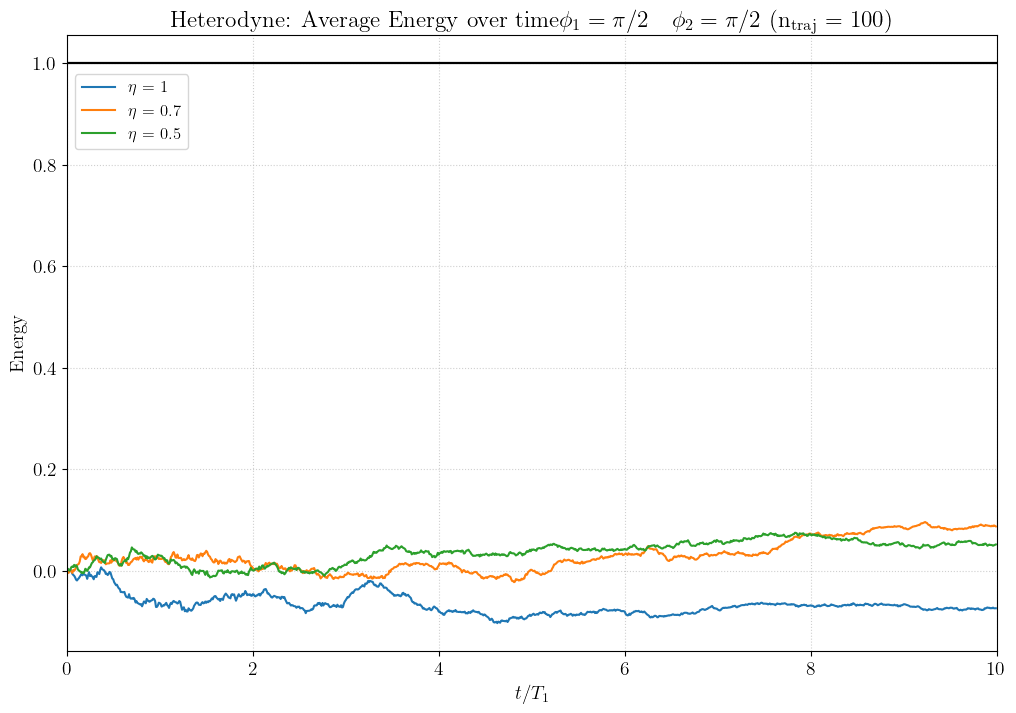

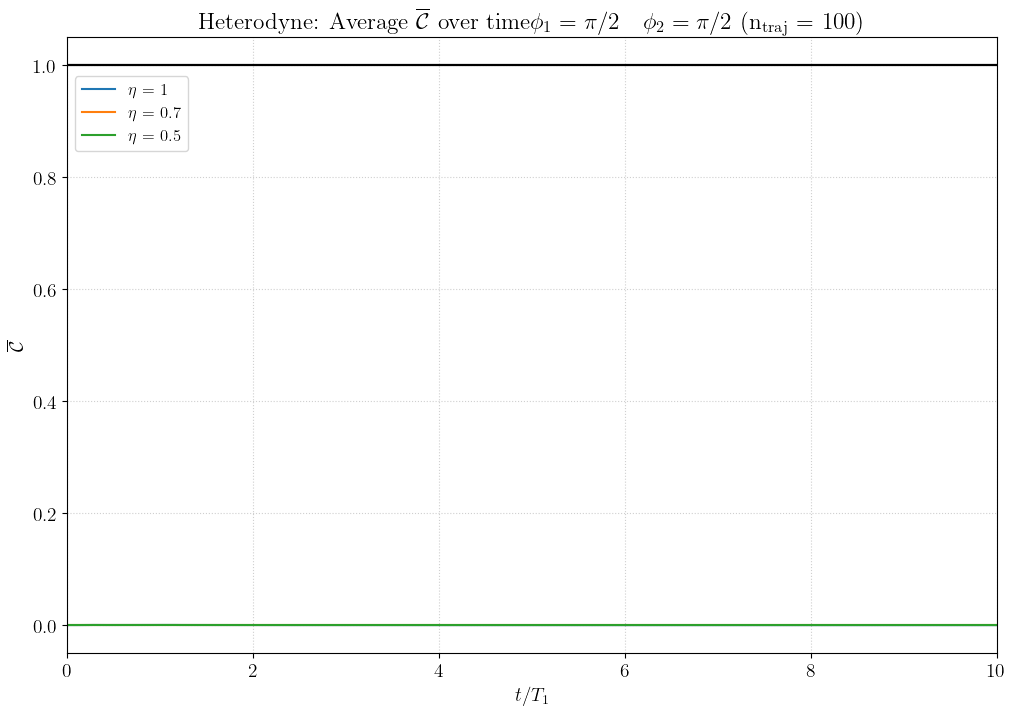

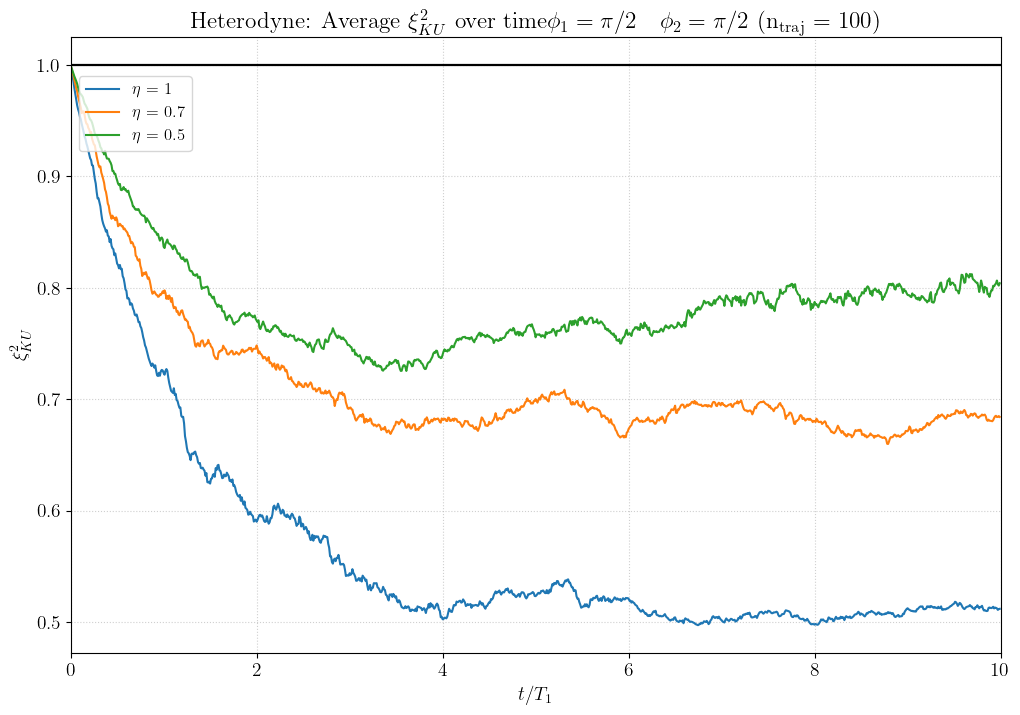

In [18]:
#theo_curves = [np.sin(theta)**2 *(1-np.exp(-gamma/2*times)) for theta in [np.pi, np.pi/2, np.pi/3, np.pi/4, np.pi/6]]

my_directory = ".\\Graphs\\Jz_Het_PlusPlus\\phi_1=pi_2_phi_2=pi_2"
Path(my_directory).mkdir(parents=True, exist_ok=True)

for e_op in columns_label:
    #Un graph per ogni e_op, al variare di eta
    plt.figure(figsize=(12,8))
    graph_name = f"Ineff_{e_op}"

    for (label, df), eta in zip(ineff_df.items(), my_eta):
        # x: tempo normalizzato a T1, y: media delle traiettorie
        x = times/T_1
        y = df[e_op]
        line_sim, = plt.plot(x, y, label=r"$\eta$ = " + str(eta))
        #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

    #plt.ylim(-0.01, 1.02)
    plt.xlim(0,10)

    plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
    #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

    plt.xlabel(r"$t/T_1$")
    plt.ylabel(label_graph_column[e_op])

    plt.title(r"Heterodyne: Average " + label_graph_column[e_op]+ r" over time"+ rf"$ \phi_1 = \pi / 2 \quad \phi_2 = \pi / 2$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

    plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
    plt.show()